This notebook is for quality control of the partially extracted Wikidata location build.

1. validate the Wikidata tables and internal consistency;
2. inspect extraction coverage, language coverage, location-kind coverage, coordinates, P31 mapping, and lookup ambiguity;
3. estimate truncation/corruption bias using QID distribution and linked-record signals;

In [ ]:
import re
import sqlite3
import textwrap
import unicodedata
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().parent

WIKIDATA_DB_PATH = PROJECT_ROOT / "data" / "names.sqlite"
GEONAMES_DB_PATH = WIKIDATA_DB_PATH

SAMPLE_LIMIT = 50
TOP_LIMIT = 50

IMPORTANT_GEO_LANGS = [
    "en", "fr", "de", "es", "it", "pt", "nl", "ru", "uk", "pl", "cs", "el", "tr", "ar", "fa", "he",
    "zh", "ja", "ko", "la", "grc", "ang", "non", "got", "cu", "hy", "ka", "kk", "tt", "mns", "kca",
]

print("PROJECT_ROOT     =", PROJECT_ROOT)
print("WIKIDATA_DB_PATH =", WIKIDATA_DB_PATH, "exists=", WIKIDATA_DB_PATH.exists())
print("GEONAMES_DB_PATH =", GEONAMES_DB_PATH, "exists=", GEONAMES_DB_PATH.exists())


PROJECT_ROOT     = /home/max/Documents/Programming/NameTransductionEngine
WIKIDATA_DB_PATH = /home/max/Documents/Programming/NameTransductionEngine/data/names.sqlite exists= True
GEONAMES_DB_PATH = /home/max/Documents/Programming/NameTransductionEngine/data/names.sqlite exists= True


## 1. Database helpers

These helpers keep queries explicit while supporting either a single merged DB or a separate attached GeoNames DB.


In [ ]:

def _same_path(a: Path, b: Path) -> bool:
    try:
        return a.resolve() == b.resolve()
    except FileNotFoundError:
        return a == b


GEO_SCHEMA = "main" if _same_path(WIKIDATA_DB_PATH, GEONAMES_DB_PATH) else "geo"


def get_conn(*, attach_geonames: bool = False) -> sqlite3.Connection:
    conn = sqlite3.connect(WIKIDATA_DB_PATH)
    conn.row_factory = sqlite3.Row
    conn.execute("PRAGMA foreign_keys = ON;")
    conn.execute("PRAGMA temp_store = MEMORY;")
    conn.execute("PRAGMA cache_size = -200000;")
    if attach_geonames and GEO_SCHEMA == "geo":
        conn.execute("ATTACH DATABASE ? AS geo;", (str(GEONAMES_DB_PATH),))
    return conn


def q(sql: str, params: Sequence | None = None, *, attach_geonames: bool = False) -> pd.DataFrame:
    sql = textwrap.dedent(sql).strip()
    with get_conn(attach_geonames=attach_geonames) as conn:
        return pd.read_sql_query(sql, conn, params=params or ())


def scalar(sql: str, params: Sequence | None = None, *, attach_geonames: bool = False):
    df = q(sql, params=params, attach_geonames=attach_geonames)
    if df.empty:
        return None
    return df.iat[0, 0]


def show(title: str, df: pd.DataFrame, *, max_rows: int | None = None) -> pd.DataFrame:
    display(Markdown(f"### {title}"))
    if max_rows is not None:
        display(df.head(max_rows))
    else:
        display(df)
    return df


def table_exists(name: str, *, schema: str = "main", attach_geonames: bool = False) -> bool:
    return bool(scalar(
        f"SELECT 1 FROM {schema}.sqlite_master WHERE type = 'table' AND name = ? LIMIT 1",
        (name,),
        attach_geonames=attach_geonames,
    ))


def index_exists(name: str, *, schema: str = "main", attach_geonames: bool = False) -> bool:
    return bool(scalar(
        f"SELECT 1 FROM {schema}.sqlite_master WHERE type = 'index' AND name = ? LIMIT 1",
        (name,),
        attach_geonames=attach_geonames,
    ))


def pct(num, den) -> float:
    if den in (0, None) or pd.isna(den):
        return float("nan")
    return 100.0 * num / den


def add_pct(df: pd.DataFrame, numerator: str, denominator: str, out_col: str = "pct") -> pd.DataFrame:
    df = df.copy()
    df[out_col] = [pct(n, d) for n, d in zip(df[numerator], df[denominator])]
    return df


def sql_in(values: Sequence[str]) -> str:
    return ", ".join("?" for _ in values)


def normalize_name_for_qc(s: str | None) -> str | None:
    """Approximation of the conservative lookup normalization: NFC + whitespace collapse + casefold."""
    if s is None:
        return None
    s = unicodedata.normalize("NFC", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s.casefold()


def has_control_chars(s: str | None) -> int:
    if not s:
        return 0
    return int(any(unicodedata.category(ch).startswith("C") for ch in s))


def qid_num_expr(col: str = "qid") -> str:
    return f"CASE WHEN {col} GLOB 'Q[0-9]*' THEN CAST(SUBSTR({col}, 2) AS INTEGER) END"


def check_required_tables() -> pd.DataFrame:
    required = [
        "wikidata_location",
        "wikidata_location_geonames",
        "wikidata_location_p31",
        "wikidata_lang_norm",
        "wikidata_location_name",
    ]
    rows = []
    for t in required:
        rows.append({"table": t, "exists": table_exists(t)})
    return pd.DataFrame(rows)

show("Required Wikidata tables", check_required_tables())


### Required Wikidata tables

,table,exists
0,wikidata_location,True
1,wikidata_location_geonames,True
2,wikidata_location_p31,True
3,wikidata_lang_norm,True
4,wikidata_location_name,True


,table,exists
0,wikidata_location,True
1,wikidata_location_geonames,True
2,wikidata_location_p31,True
3,wikidata_lang_norm,True
4,wikidata_location_name,True


## 2. Schema, counts, and integrity checks

This section checks that the extraction produced the expected tables and that there are no obvious orphaned records. It does **not** assume SQLite foreign keys were enforced during import.


In [3]:

expected_wd_columns = {
    "wikidata_location": ["qid", "kind", "lat", "lon"],
    "wikidata_location_geonames": ["qid", "geonames_id"],
    "wikidata_location_p31": ["qid", "p31_qid"],
    "wikidata_lang_norm": ["wd_lang", "geo_lang", "iso639_3", "iso639_1"],
    "wikidata_location_name": ["qid", "wd_lang", "geo_lang", "name", "name_norm", "term_type"],
}

schema_rows = []
for table, expected_cols in expected_wd_columns.items():
    if not table_exists(table):
        schema_rows.append({"table": table, "status": "MISSING", "missing_columns": ", ".join(expected_cols), "extra_columns": ""})
        continue
    cols = q(f"PRAGMA table_info({table})")
    actual = cols["name"].tolist()
    schema_rows.append({
        "table": table,
        "status": "ok" if set(expected_cols).issubset(actual) else "column mismatch",
        "missing_columns": ", ".join([c for c in expected_cols if c not in actual]),
        "extra_columns": ", ".join([c for c in actual if c not in expected_cols]),
        "actual_columns": ", ".join(actual),
    })

show("Wikidata schema check", pd.DataFrame(schema_rows))

count_sql = """
SELECT 'wikidata_location' AS table_name, COUNT(*) AS rows FROM wikidata_location
UNION ALL SELECT 'wikidata_location_name', COUNT(*) FROM wikidata_location_name
UNION ALL SELECT 'wikidata_location_p31', COUNT(*) FROM wikidata_location_p31
UNION ALL SELECT 'wikidata_location_geonames', COUNT(*) FROM wikidata_location_geonames
UNION ALL SELECT 'wikidata_lang_norm', COUNT(*) FROM wikidata_lang_norm
"""
wd_counts = q(count_sql)
show("Wikidata table row counts", wd_counts)

with get_conn() as conn:
    integrity_check = pd.DataFrame(conn.execute("PRAGMA integrity_check;").fetchall(), columns=["integrity_check"])
    foreign_key_check = pd.DataFrame(conn.execute("PRAGMA foreign_key_check;").fetchall())

show("SQLite integrity_check", integrity_check)
show("SQLite foreign_key_check", foreign_key_check if not foreign_key_check.empty else pd.DataFrame([{"result": "no FK violations reported"}]))


### Wikidata schema check

,table,status,missing_columns,extra_columns,actual_columns
0,wikidata_location,ok,,,"qid, kind, lat, lon"
1,wikidata_location_geonames,ok,,,"qid, geonames_id"
2,wikidata_location_p31,ok,,,"qid, p31_qid"
3,wikidata_lang_norm,ok,,,"wd_lang, geo_lang, iso639_3, iso639_1"
4,wikidata_location_name,ok,,,"qid, wd_lang, geo_lang, name, name_norm, term_type"


### Wikidata table row counts

,table_name,rows
0,wikidata_location,1275439
1,wikidata_location_name,7156042
2,wikidata_location_p31,1468972
3,wikidata_location_geonames,740045
4,wikidata_lang_norm,531


### SQLite integrity_check

,integrity_check
0,ok


### SQLite foreign_key_check

,result
0,no FK violations reported


,result
0,no FK violations reported


In [4]:

internal_consistency = q("""
WITH metrics AS (
    SELECT 'names with missing parent qid' AS check_name, COUNT(*) AS n
    FROM wikidata_location_name n
    LEFT JOIN wikidata_location l ON l.qid = n.qid
    WHERE l.qid IS NULL

    UNION ALL
    SELECT 'p31 rows with missing parent qid', COUNT(*)
    FROM wikidata_location_p31 p
    LEFT JOIN wikidata_location l ON l.qid = p.qid
    WHERE l.qid IS NULL

    UNION ALL
    SELECT 'GeoNames link rows with missing parent qid', COUNT(*)
    FROM wikidata_location_geonames g
    LEFT JOIN wikidata_location l ON l.qid = g.qid
    WHERE l.qid IS NULL

    UNION ALL
    SELECT 'name rows with wd_lang missing from wikidata_lang_norm', COUNT(*)
    FROM wikidata_location_name n
    LEFT JOIN wikidata_lang_norm ln ON ln.wd_lang = n.wd_lang
    WHERE ln.wd_lang IS NULL

    UNION ALL
    SELECT 'name rows where stored geo_lang disagrees with wikidata_lang_norm', COUNT(*)
    FROM wikidata_location_name n
    JOIN wikidata_lang_norm ln ON ln.wd_lang = n.wd_lang
    WHERE COALESCE(n.geo_lang, '') <> COALESCE(ln.geo_lang, '')

    UNION ALL
    SELECT 'locations with no names', COUNT(*)
    FROM wikidata_location l
    LEFT JOIN wikidata_location_name n ON n.qid = l.qid
    WHERE n.qid IS NULL

    UNION ALL
    SELECT 'locations with no P31 row', COUNT(*)
    FROM wikidata_location l
    LEFT JOIN wikidata_location_p31 p ON p.qid = l.qid
    WHERE p.qid IS NULL
)
SELECT * FROM metrics ORDER BY n DESC;
""")
show("Internal consistency checks", internal_consistency)


### Internal consistency checks

,check_name,n
0,locations with no names,55
1,names with missing parent qid,0
2,p31 rows with missing parent qid,0
3,GeoNames link rows with missing parent qid,0
4,name rows with wd_lang missing from wikidata_lang_norm,0
5,name rows where stored geo_lang disagrees with wikidata_lang_norm,0
6,locations with no P31 row,0


,check_name,n
0,locations with no names,55
1,names with missing parent qid,0
2,p31 rows with missing parent qid,0
3,GeoNames link rows with missing parent qid,0
4,name rows with wd_lang missing from wikidata_lang_norm,0
5,name rows where stored geo_lang disagrees with wikidata_lang_norm,0
6,locations with no P31 row,0


## 3. Wikidata extraction overview

These are the high-level survival metrics for the corrupted dump build: how many locations survived, how many have coordinates, names, language mappings, P31 values, and GeoNames links.


In [5]:

overview = q("""
WITH
name_counts AS (
    SELECT
        qid,
        COUNT(*) AS name_rows,
        COUNT(DISTINCT wd_lang) AS wd_langs,
        COUNT(DISTINCT geo_lang) AS geo_langs,
        SUM(CASE WHEN geo_lang IS NULL THEN 1 ELSE 0 END) AS unmapped_name_rows
    FROM wikidata_location_name
    GROUP BY qid
),
p31_counts AS (
    SELECT qid, COUNT(DISTINCT p31_qid) AS p31_count
    FROM wikidata_location_p31
    GROUP BY qid
),
geonames_counts AS (
    SELECT qid, COUNT(DISTINCT geonames_id) AS geonames_ids
    FROM wikidata_location_geonames
    GROUP BY qid
)
SELECT
    COUNT(*) AS locations,
    SUM(CASE WHEN l.lat IS NOT NULL AND l.lon IS NOT NULL THEN 1 ELSE 0 END) AS with_coords,
    SUM(CASE WHEN COALESCE(n.name_rows, 0) > 0 THEN 1 ELSE 0 END) AS with_names,
    SUM(CASE WHEN COALESCE(n.geo_langs, 0) > 0 THEN 1 ELSE 0 END) AS with_mapped_geo_lang,
    SUM(CASE WHEN COALESCE(p.p31_count, 0) > 0 THEN 1 ELSE 0 END) AS with_p31,
    SUM(CASE WHEN COALESCE(g.geonames_ids, 0) > 0 THEN 1 ELSE 0 END) AS with_geonames_link,
    SUM(COALESCE(n.name_rows, 0)) AS total_name_rows,
    SUM(COALESCE(n.unmapped_name_rows, 0)) AS total_unmapped_name_rows,
    AVG(COALESCE(n.name_rows, 0)) AS avg_names_per_location,
    AVG(COALESCE(n.geo_langs, 0)) AS avg_geo_langs_per_location
FROM wikidata_location l
LEFT JOIN name_counts n ON n.qid = l.qid
LEFT JOIN p31_counts p ON p.qid = l.qid
LEFT JOIN geonames_counts g ON g.qid = l.qid;
""")
for col in ["with_coords", "with_names", "with_mapped_geo_lang", "with_p31", "with_geonames_link"]:
    overview[col + "_pct"] = overview[col] / overview["locations"] * 100
if int(overview.loc[0, "total_name_rows"] or 0):
    overview["unmapped_name_rows_pct"] = overview["total_unmapped_name_rows"] / overview["total_name_rows"] * 100
show("Wikidata extraction overview", overview.T.reset_index().rename(columns={"index": "metric", 0: "value"}))


### Wikidata extraction overview

,metric,value
0,locations,1.275439e+06
1,with_coords,1.115577e+06
2,with_names,1.275384e+06
3,with_mapped_geo_lang,1.275384e+06
4,with_p31,1.275439e+06
5,with_geonames_link,7.294560e+05
6,total_name_rows,7.156042e+06
7,total_unmapped_name_rows,0.000000e+00
8,avg_names_per_location,5.610650e+00
9,avg_geo_langs_per_location,5.381324e+00


,metric,value
0,locations,1.275439e+06
1,with_coords,1.115577e+06
2,with_names,1.275384e+06
3,with_mapped_geo_lang,1.275384e+06
4,with_p31,1.275439e+06
5,with_geonames_link,7.294560e+05
6,total_name_rows,7.156042e+06
7,total_unmapped_name_rows,0.000000e+00
8,avg_names_per_location,5.610650e+00
9,avg_geo_langs_per_location,5.381324e+00


In [6]:

kind_overview = q("""
WITH
name_counts AS (
    SELECT
        qid,
        COUNT(*) AS name_rows,
        COUNT(DISTINCT wd_lang) AS wd_langs,
        COUNT(DISTINCT geo_lang) AS geo_langs,
        SUM(CASE WHEN geo_lang IS NULL THEN 1 ELSE 0 END) AS unmapped_name_rows
    FROM wikidata_location_name
    GROUP BY qid
),
p31_counts AS (
    SELECT qid, COUNT(DISTINCT p31_qid) AS p31_count
    FROM wikidata_location_p31
    GROUP BY qid
),
geonames_counts AS (
    SELECT qid, COUNT(DISTINCT geonames_id) AS geonames_ids
    FROM wikidata_location_geonames
    GROUP BY qid
)
SELECT
    l.kind,
    COUNT(*) AS locations,
    SUM(CASE WHEN l.lat IS NOT NULL AND l.lon IS NOT NULL THEN 1 ELSE 0 END) AS with_coords,
    SUM(CASE WHEN COALESCE(n.name_rows, 0) > 0 THEN 1 ELSE 0 END) AS with_names,
    SUM(CASE WHEN COALESCE(n.geo_langs, 0) > 0 THEN 1 ELSE 0 END) AS with_mapped_geo_lang,
    SUM(CASE WHEN COALESCE(g.geonames_ids, 0) > 0 THEN 1 ELSE 0 END) AS with_geonames_link,
    SUM(COALESCE(n.name_rows, 0)) AS name_rows,
    AVG(COALESCE(n.name_rows, 0)) AS avg_names,
    AVG(COALESCE(n.geo_langs, 0)) AS avg_geo_langs,
    AVG(COALESCE(p.p31_count, 0)) AS avg_p31
FROM wikidata_location l
LEFT JOIN name_counts n ON n.qid = l.qid
LEFT JOIN p31_counts p ON p.qid = l.qid
LEFT JOIN geonames_counts g ON g.qid = l.qid
GROUP BY l.kind
ORDER BY locations DESC;
""")
for col in ["with_coords", "with_names", "with_mapped_geo_lang", "with_geonames_link"]:
    kind_overview[col + "_pct"] = kind_overview[col] / kind_overview["locations"] * 100
show("Coverage by Wikidata-derived NTE kind", kind_overview)


### Coverage by Wikidata-derived NTE kind

,kind,locations,with_coords,with_names,with_mapped_geo_lang,with_geonames_link,name_rows,avg_names,avg_geo_langs,avg_p31,with_coords_pct,with_names_pct,with_mapped_geo_lang_pct,with_geonames_link_pct
0,settlement,360459,268479,360433,360433,154417,2182032,6.053482,5.730541,1.194688,74.482535,99.992787,99.992787,42.838991
1,river,272885,259413,272883,272883,226286,1156918,4.239581,4.074163,1.038687,95.063122,99.999267,99.999267,82.923576
2,lake,183555,181702,183545,183545,112925,653083,3.557969,3.505979,1.064662,98.990493,99.994552,99.994552,61.521070
3,village,161326,129900,161317,161317,50297,1230636,7.628256,7.416002,1.267161,80.520189,99.994421,99.994421,31.177244
4,island,96844,96093,96844,96844,88086,436365,4.505855,4.405787,1.022882,99.224526,100.000000,100.000000,90.956590
5,hamlet,95151,83884,95151,95151,20171,360877,3.792677,3.719456,1.345304,88.158821,100.000000,100.000000,21.198936
6,bay,33376,33270,33376,33376,26975,96130,2.880213,2.821968,1.028883,99.682407,100.000000,100.000000,80.821548
7,peninsula,18496,18418,18496,18496,16356,74659,4.036494,3.935013,1.027790,99.578287,100.000000,100.000000,88.429931
8,mountain_range,14640,14055,14640,14640,12414,102925,7.030396,6.825546,1.067623,96.004098,100.000000,100.000000,84.795082
9,town,11202,10859,11201,11201,8763,222256,19.840743,18.572130,1.458668,96.938047,99.991073,99.991073,78.227102


,kind,locations,with_coords,with_names,with_mapped_geo_lang,with_geonames_link,name_rows,avg_names,avg_geo_langs,avg_p31,with_coords_pct,with_names_pct,with_mapped_geo_lang_pct,with_geonames_link_pct
0,settlement,360459,268479,360433,360433,154417,2182032,6.053482,5.730541,1.194688,74.482535,99.992787,99.992787,42.838991
1,river,272885,259413,272883,272883,226286,1156918,4.239581,4.074163,1.038687,95.063122,99.999267,99.999267,82.923576
2,lake,183555,181702,183545,183545,112925,653083,3.557969,3.505979,1.064662,98.990493,99.994552,99.994552,61.521070
3,village,161326,129900,161317,161317,50297,1230636,7.628256,7.416002,1.267161,80.520189,99.994421,99.994421,31.177244
4,island,96844,96093,96844,96844,88086,436365,4.505855,4.405787,1.022882,99.224526,100.000000,100.000000,90.956590
5,hamlet,95151,83884,95151,95151,20171,360877,3.792677,3.719456,1.345304,88.158821,100.000000,100.000000,21.198936
6,bay,33376,33270,33376,33376,26975,96130,2.880213,2.821968,1.028883,99.682407,100.000000,100.000000,80.821548
7,peninsula,18496,18418,18496,18496,16356,74659,4.036494,3.935013,1.027790,99.578287,100.000000,100.000000,88.429931
8,mountain_range,14640,14055,14640,14640,12414,102925,7.030396,6.825546,1.067623,96.004098,100.000000,100.000000,84.795082
9,town,11202,10859,11201,11201,8763,222256,19.840743,18.572130,1.458668,96.938047,99.991073,99.991073,78.227102


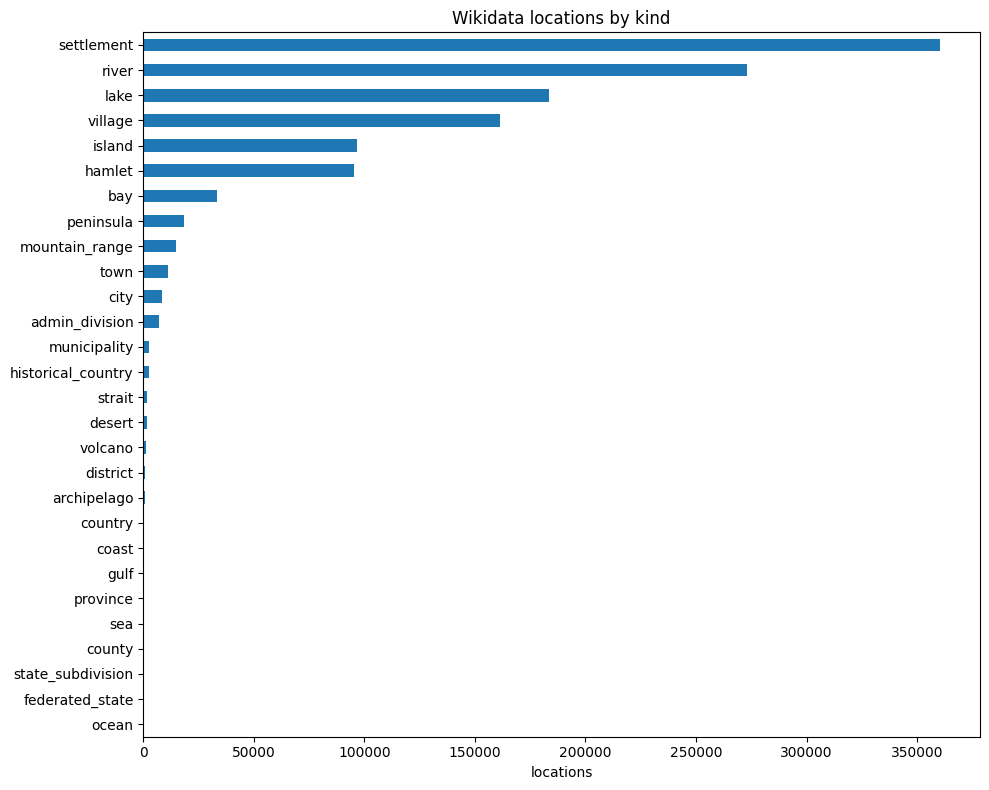

In [7]:

# Visual overview: location count by kind, limited to top categories.
plot_df = kind_overview.head(30).sort_values("locations")
ax = plot_df.plot.barh(x="kind", y="locations", legend=False, figsize=(10, 8))
ax.set_title("Wikidata locations by kind")
ax.set_xlabel("locations")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 4. Entity-level name and language coverage

The central question for NTE is not just “how many places survived,” but whether each surviving place has enough language labels to be useful as lookup data.


In [8]:

name_bucket_distribution = q("""
WITH name_counts AS (
    SELECT l.qid, l.kind, COUNT(n.name) AS name_rows, COUNT(DISTINCT n.geo_lang) AS geo_langs
    FROM wikidata_location l
    LEFT JOIN wikidata_location_name n ON n.qid = l.qid
    GROUP BY l.qid, l.kind
), bucketed AS (
    SELECT
        kind,
        CASE
            WHEN name_rows = 0 THEN '00 no names'
            WHEN name_rows = 1 THEN '01 one name'
            WHEN name_rows BETWEEN 2 AND 3 THEN '02 2-3 names'
            WHEN name_rows BETWEEN 4 AND 5 THEN '03 4-5 names'
            WHEN name_rows BETWEEN 6 AND 10 THEN '04 6-10 names'
            WHEN name_rows BETWEEN 11 AND 25 THEN '05 11-25 names'
            WHEN name_rows BETWEEN 26 AND 50 THEN '06 26-50 names'
            ELSE '07 >50 names'
        END AS name_bucket,
        COUNT(*) AS locations
    FROM name_counts
    GROUP BY kind, name_bucket
)
SELECT * FROM bucketed ORDER BY kind, name_bucket;
""")
show("Name-count buckets by kind", name_bucket_distribution)


### Name-count buckets by kind

,kind,name_bucket,locations
0,admin_division,00 no names,5
1,admin_division,01 one name,3628
2,admin_division,02 2-3 names,1901
3,admin_division,03 4-5 names,466
4,admin_division,04 6-10 names,516
5,admin_division,05 11-25 names,259
6,admin_division,06 26-50 names,106
7,admin_division,07 >50 names,61
8,archipelago,01 one name,36
9,archipelago,02 2-3 names,142


,kind,name_bucket,locations
0,admin_division,00 no names,5
1,admin_division,01 one name,3628
2,admin_division,02 2-3 names,1901
3,admin_division,03 4-5 names,466
4,admin_division,04 6-10 names,516
5,admin_division,05 11-25 names,259
6,admin_division,06 26-50 names,106
7,admin_division,07 >50 names,61
8,archipelago,01 one name,36
9,archipelago,02 2-3 names,142


In [9]:

lang_bucket_distribution = q("""
WITH lang_counts AS (
    SELECT l.qid, l.kind, COUNT(DISTINCT n.geo_lang) AS geo_langs
    FROM wikidata_location l
    LEFT JOIN wikidata_location_name n ON n.qid = l.qid AND n.geo_lang IS NOT NULL
    GROUP BY l.qid, l.kind
), bucketed AS (
    SELECT
        kind,
        CASE
            WHEN geo_langs = 0 THEN '00 no mapped languages'
            WHEN geo_langs = 1 THEN '01 one language'
            WHEN geo_langs BETWEEN 2 AND 3 THEN '02 2-3 languages'
            WHEN geo_langs BETWEEN 4 AND 5 THEN '03 4-5 languages'
            WHEN geo_langs BETWEEN 6 AND 10 THEN '04 6-10 languages'
            WHEN geo_langs BETWEEN 11 AND 25 THEN '05 11-25 languages'
            WHEN geo_langs BETWEEN 26 AND 50 THEN '06 26-50 languages'
            ELSE '07 >50 languages'
        END AS geo_lang_bucket,
        COUNT(*) AS locations
    FROM lang_counts
    GROUP BY kind, geo_lang_bucket
)
SELECT * FROM bucketed ORDER BY kind, geo_lang_bucket;
""")
show("Mapped-language buckets by kind", lang_bucket_distribution)


### Mapped-language buckets by kind

,kind,geo_lang_bucket,locations
0,admin_division,00 no mapped languages,5
1,admin_division,01 one language,3662
2,admin_division,02 2-3 languages,1921
3,admin_division,03 4-5 languages,483
4,admin_division,04 6-10 languages,476
5,admin_division,05 11-25 languages,242
6,admin_division,06 26-50 languages,96
7,admin_division,07 >50 languages,57
8,archipelago,01 one language,36
9,archipelago,02 2-3 languages,143


,kind,geo_lang_bucket,locations
0,admin_division,00 no mapped languages,5
1,admin_division,01 one language,3662
2,admin_division,02 2-3 languages,1921
3,admin_division,03 4-5 languages,483
4,admin_division,04 6-10 languages,476
5,admin_division,05 11-25 languages,242
6,admin_division,06 26-50 languages,96
7,admin_division,07 >50 languages,57
8,archipelago,01 one language,36
9,archipelago,02 2-3 languages,143


In [10]:

important_placeholders = sql_in(IMPORTANT_GEO_LANGS)
important_lang_coverage = q(f"""
WITH total AS (
    SELECT COUNT(*) AS locations FROM wikidata_location
), per_lang AS (
    SELECT
        n.geo_lang,
        COUNT(*) AS name_rows,
        COUNT(DISTINCT n.qid) AS locations_with_lang
    FROM wikidata_location_name n
    WHERE n.geo_lang IN ({important_placeholders})
    GROUP BY n.geo_lang
)
SELECT
    p.geo_lang,
    p.name_rows,
    p.locations_with_lang,
    ROUND(100.0 * p.locations_with_lang / total.locations, 3) AS locations_pct
FROM per_lang p CROSS JOIN total
ORDER BY locations_with_lang DESC;
""", IMPORTANT_GEO_LANGS)
show("Coverage for important language buckets", important_lang_coverage)


### Coverage for important language buckets

,geo_lang,name_rows,locations_with_lang,locations_pct
0,en,936961,900270,70.585
1,nl,323112,323112,25.333
2,fr,288621,288621,22.629
3,ru,208516,208516,16.349
4,es,181681,181599,14.238
5,de,168453,155003,12.153
6,tt,123027,122686,9.619
7,tr,120061,120061,9.413
8,pl,108879,108879,8.537
9,uk,100649,100649,7.891


,geo_lang,name_rows,locations_with_lang,locations_pct
0,en,936961,900270,70.585
1,nl,323112,323112,25.333
2,fr,288621,288621,22.629
3,ru,208516,208516,16.349
4,es,181681,181599,14.238
5,de,168453,155003,12.153
6,tt,123027,122686,9.619
7,tr,120061,120061,9.413
8,pl,108879,108879,8.537
9,uk,100649,100649,7.891


In [11]:

important_by_kind_exprs = []
params = []
for lang in IMPORTANT_GEO_LANGS:
    safe_col = re.sub(r"[^0-9A-Za-z_]", "_", lang)
    important_by_kind_exprs.append(f"SUM(CASE WHEN f.has_{safe_col} = 1 THEN 1 ELSE 0 END) AS has_{safe_col}")

flag_exprs = []
for lang in IMPORTANT_GEO_LANGS:
    safe_col = re.sub(r"[^0-9A-Za-z_]", "_", lang)
    flag_exprs.append(f"MAX(CASE WHEN geo_lang = ? THEN 1 ELSE 0 END) AS has_{safe_col}")
    params.append(lang)

important_by_kind = q(f"""
WITH flags AS (
    SELECT qid, {", ".join(flag_exprs)}
    FROM wikidata_location_name
    GROUP BY qid
)
SELECT
    l.kind,
    COUNT(*) AS locations,
    {", ".join(important_by_kind_exprs)}
FROM wikidata_location l
LEFT JOIN flags f ON f.qid = l.qid
GROUP BY l.kind
ORDER BY locations DESC;
""", params)

# Add percentages for easier scanning.
for lang in IMPORTANT_GEO_LANGS:
    col = "has_" + re.sub(r"[^0-9A-Za-z_]", "_", lang)
    if col in important_by_kind.columns:
        important_by_kind[col + "_pct"] = important_by_kind[col] / important_by_kind["locations"] * 100

show("Important-language entity coverage by kind", important_by_kind)


### Important-language entity coverage by kind

,kind,locations,has_en,has_fr,has_de,has_es,has_it,has_pt,has_nl,has_ru,has_uk,has_pl,has_cs,has_el,has_tr,has_ar,has_fa,has_he,has_zh,has_ja,has_ko,has_la,has_grc,has_ang,has_non,has_got,has_cu,has_hy,has_ka,has_kk,has_tt,has_mns,has_kca,has_en_pct,has_fr_pct,has_de_pct,has_es_pct,has_it_pct,has_pt_pct,has_nl_pct,has_ru_pct,has_uk_pct,has_pl_pct,has_cs_pct,has_el_pct,has_tr_pct,has_ar_pct,has_fa_pct,has_he_pct,has_zh_pct,has_ja_pct,has_ko_pct,has_la_pct,has_grc_pct,has_ang_pct,has_non_pct,has_got_pct,has_cu_pct,has_hy_pct,has_ka_pct,has_kk_pct,has_tt_pct,has_mns_pct,has_kca_pct
0,settlement,360459,218581,59155,44901,122007,36020,30446,166166,32142,16062,39760,22951,8715,36627,25678,22793,2194,9496,9266,1730,466,32,49,0,15,9,4371,5735,2570,76096,0,0,60.639629,16.411020,12.456618,33.847678,9.992815,8.446453,46.098447,8.916964,4.455985,11.030381,6.367160,2.417751,10.161211,7.123695,6.323327,0.608668,2.634419,2.570611,0.479944,0.129280,0.008878,0.013594,0.0,0.004161,0.002497,1.212621,1.591027,0.712980,21.110861,0.0,0.0
1,river,272885,216530,16102,23439,13338,5698,6026,21058,45717,7468,5767,3460,1249,4236,1802,3271,1241,10898,6492,1060,891,60,42,0,12,11,7349,999,17112,16916,0,0,79.348443,5.900654,8.589333,4.887773,2.088059,2.208256,7.716804,16.753211,2.736684,2.113344,1.267933,0.457702,1.552302,0.660351,1.198673,0.454770,3.993624,2.379024,0.388442,0.326511,0.021987,0.015391,0.0,0.004397,0.004031,2.693076,0.366088,6.270773,6.198948,0.0,0.0
2,lake,183555,134854,116327,11965,3237,2430,846,3687,8182,1187,3160,1045,234,4758,979,728,367,5489,1264,231,119,4,14,0,9,1,342,443,519,108,0,0,73.467898,63.374465,6.518482,1.763504,1.323854,0.460897,2.008662,4.457520,0.646673,1.721555,0.569312,0.127482,2.592139,0.533355,0.396611,0.199940,2.990384,0.688622,0.125848,0.064831,0.002179,0.007627,0.0,0.004903,0.000545,0.186320,0.241345,0.282749,0.058838,0.0,0.0
3,village,161326,120991,45404,29254,14675,19927,9778,75909,38508,30871,36024,5073,3257,15477,19967,46688,1586,4775,4760,1268,1825,16,230,0,8,9,10090,3649,2026,15354,0,0,74.997830,28.144254,18.133469,9.096488,12.352008,6.061019,47.053172,23.869680,19.135787,22.329941,3.144564,2.018893,9.593618,12.376802,28.940158,0.983103,2.959845,2.950547,0.785986,1.131250,0.009918,0.142568,0.0,0.004959,0.005579,6.254417,2.261880,1.255842,9.517375,0.0,0.0
4,island,96844,74824,17908,8169,4526,3535,1891,16563,4323,1841,2131,1332,1087,44160,1861,1042,992,4729,4033,1849,392,31,75,0,17,1,508,492,148,139,0,0,77.262401,18.491595,8.435215,4.673496,3.650200,1.952625,17.102763,4.463880,1.900995,2.200446,1.375408,1.122424,45.599108,1.921647,1.075957,1.024328,4.883111,4.164429,1.909256,0.404775,0.032010,0.077444,0.0,0.017554,0.001033,0.524555,0.508034,0.152823,0.143530,0.0,0.0
5,hamlet,95151,42121,8267,14363,4112,2659,1955,7481,60322,30723,6060,1957,30,1023,123,2362,67,333,378,30,768,1,11,0,3,3,8026,1539,2071,8573,0,0,44.267533,8.688295,15.094954,4.321552,2.794506,2.054629,7.862240,63.396076,32.288678,6.368824,2.056731,0.031529,1.075133,0.129268,2.482370,0.070414,0.349970,0.397263,0.031529,0.807138,0.001051,0.011561,0.0,0.003153,0.003153,8.435014,1.617429,2.176540,9.009890,0.0,0.0
6,bay,33376,30648,1992,1905,837,654,301,750,834,325,523,301,338,868,208,185,386,1149,759,178,47,4,6,0,1,0,76,78,39,29,0,0,91.826462,5.968360,5.707694,2.507790,1.959492,0.901846,2.247124,2.498802,0.973754,1.566994,0.901846,1.012704,2.600671,0.623202,0.554291,1.156520,3.442593,2.274089,0.533317,0.140820,0.011985,0.017977,0.0,0.002996,0.000000,0.227709,0.233701,0.116850,0.086889,0.0,0.0
7,peninsula,18496,16133,1174,1577,993,401,280,8086,461,207,310,605,91,809,144,106,280,867,360,129,60,5,13,0,2,1,76,57,43,25,0,0,87.224265,6.347318,8.526168,5.368728,2.168036,1.513841,43.717561,2.492431,1.119161,1.676038,3.270978,0.491998,4.373919,0.778547,0.573097,1.513841,4.687500,1.946367,0.697448,0.324394,0.027033,0.070285,0.0,0.010813,0.005407,0.410900,0.308175,0.232483,0.135164,0.0,0.0
8,mountain_range,14640,12648,1626,2297,1666,1266,638,2882,1977,778,1196,1199,2

,kind,locations,has_en,has_fr,has_de,has_es,has_it,has_pt,has_nl,has_ru,has_uk,has_pl,has_cs,has_el,has_tr,has_ar,has_fa,has_he,has_zh,has_ja,has_ko,has_la,has_grc,has_ang,has_non,has_got,has_cu,has_hy,has_ka,has_kk,has_tt,has_mns,has_kca,has_en_pct,has_fr_pct,has_de_pct,has_es_pct,has_it_pct,has_pt_pct,has_nl_pct,has_ru_pct,has_uk_pct,has_pl_pct,has_cs_pct,has_el_pct,has_tr_pct,has_ar_pct,has_fa_pct,has_he_pct,has_zh_pct,has_ja_pct,has_ko_pct,has_la_pct,has_grc_pct,has_ang_pct,has_non_pct,has_got_pct,has_cu_pct,has_hy_pct,has_ka_pct,has_kk_pct,has_tt_pct,has_mns_pct,has_kca_pct
0,settlement,360459,218581,59155,44901,122007,36020,30446,166166,32142,16062,39760,22951,8715,36627,25678,22793,2194,9496,9266,1730,466,32,49,0,15,9,4371,5735,2570,76096,0,0,60.639629,16.411020,12.456618,33.847678,9.992815,8.446453,46.098447,8.916964,4.455985,11.030381,6.367160,2.417751,10.161211,7.123695,6.323327,0.608668,2.634419,2.570611,0.479944,0.129280,0.008878,0.013594,0.0,0.004161,0.002497,1.212621,1.591027,0.712980,21.110861,0.0,0.0
1,river,272885,216530,16102,23439,13338,5698,6026,21058,45717,7468,5767,3460,1249,4236,1802,3271,1241,10898,6492,1060,891,60,42,0,12,11,7349,999,17112,16916,0,0,79.348443,5.900654,8.589333,4.887773,2.088059,2.208256,7.716804,16.753211,2.736684,2.113344,1.267933,0.457702,1.552302,0.660351,1.198673,0.454770,3.993624,2.379024,0.388442,0.326511,0.021987,0.015391,0.0,0.004397,0.004031,2.693076,0.366088,6.270773,6.198948,0.0,0.0
2,lake,183555,134854,116327,11965,3237,2430,846,3687,8182,1187,3160,1045,234,4758,979,728,367,5489,1264,231,119,4,14,0,9,1,342,443,519,108,0,0,73.467898,63.374465,6.518482,1.763504,1.323854,0.460897,2.008662,4.457520,0.646673,1.721555,0.569312,0.127482,2.592139,0.533355,0.396611,0.199940,2.990384,0.688622,0.125848,0.064831,0.002179,0.007627,0.0,0.004903,0.000545,0.186320,0.241345,0.282749,0.058838,0.0,0.0
3,village,161326,120991,45404,29254,14675,19927,9778,75909,38508,30871,36024,5073,3257,15477,19967,46688,1586,4775,4760,1268,1825,16,230,0,8,9,10090,3649,2026,15354,0,0,74.997830,28.144254,18.133469,9.096488,12.352008,6.061019,47.053172,23.869680,19.135787,22.329941,3.144564,2.018893,9.593618,12.376802,28.940158,0.983103,2.959845,2.950547,0.785986,1.131250,0.009918,0.142568,0.0,0.004959,0.005579,6.254417,2.261880,1.255842,9.517375,0.0,0.0
4,island,96844,74824,17908,8169,4526,3535,1891,16563,4323,1841,2131,1332,1087,44160,1861,1042,992,4729,4033,1849,392,31,75,0,17,1,508,492,148,139,0,0,77.262401,18.491595,8.435215,4.673496,3.650200,1.952625,17.102763,4.463880,1.900995,2.200446,1.375408,1.122424,45.599108,1.921647,1.075957,1.024328,4.883111,4.164429,1.909256,0.404775,0.032010,0.077444,0.0,0.017554,0.001033,0.524555,0.508034,0.152823,0.143530,0.0,0.0
5,hamlet,95151,42121,8267,14363,4112,2659,1955,7481,60322,30723,6060,1957,30,1023,123,2362,67,333,378,30,768,1,11,0,3,3,8026,1539,2071,8573,0,0,44.267533,8.688295,15.094954,4.321552,2.794506,2.054629,7.862240,63.396076,32.288678,6.368824,2.056731,0.031529,1.075133,0.129268,2.482370,0.070414,0.349970,0.397263,0.031529,0.807138,0.001051,0.011561,0.0,0.003153,0.003153,8.435014,1.617429,2.176540,9.009890,0.0,0.0
6,bay,33376,30648,1992,1905,837,654,301,750,834,325,523,301,338,868,208,185,386,1149,759,178,47,4,6,0,1,0,76,78,39,29,0,0,91.826462,5.968360,5.707694,2.507790,1.959492,0.901846,2.247124,2.498802,0.973754,1.566994,0.901846,1.012704,2.600671,0.623202,0.554291,1.156520,3.442593,2.274089,0.533317,0.140820,0.011985,0.017977,0.0,0.002996,0.000000,0.227709,0.233701,0.116850,0.086889,0.0,0.0
7,peninsula,18496,16133,1174,1577,993,401,280,8086,461,207,310,605,91,809,144,106,280,867,360,129,60,5,13,0,2,1,76,57,43,25,0,0,87.224265,6.347318,8.526168,5.368728,2.168036,1.513841,43.717561,2.492431,1.119161,1.676038,3.270978,0.491998,4.373919,0.778547,0.573097,1.513841,4.687500,1.946367,0.697448,0.324394,0.027033,0.070285,0.0,0.010813,0.005407,0.410900,0.308175,0.232483,0.135164,0.0,0.0
8,mountain_range,14640,12648,1626,2297,1666,1266,638,2882,1977,778,1196,1199,2

In [12]:

poorly_covered_samples = q(f"""
WITH lang_counts AS (
    SELECT l.qid, l.kind, COUNT(DISTINCT n.geo_lang) AS geo_langs, COUNT(n.name) AS name_rows
    FROM wikidata_location l
    LEFT JOIN wikidata_location_name n ON n.qid = l.qid AND n.geo_lang IS NOT NULL
    GROUP BY l.qid, l.kind
)
SELECT lc.*, l.lat, l.lon
FROM lang_counts lc
JOIN wikidata_location l ON l.qid = lc.qid
WHERE lc.geo_langs <= 1
ORDER BY lc.kind, lc.geo_langs, lc.name_rows
LIMIT {SAMPLE_LIMIT};
""")
show("Sample: locations with 0-1 mapped languages", poorly_covered_samples)


### Sample: locations with 0-1 mapped languages

,qid,kind,geo_langs,name_rows,lat,lon
0,Q123143782,admin_division,0,0,NaN,NaN
1,Q131282046,admin_division,0,0,NaN,NaN
2,Q131282058,admin_division,0,0,NaN,NaN
3,Q134302145,admin_division,0,0,36.866700,42.983300
4,Q135583790,admin_division,0,0,NaN,NaN
5,Q100706472,admin_division,1,1,NaN,NaN
6,Q101067847,admin_division,1,1,NaN,NaN
7,Q101481654,admin_division,1,1,NaN,NaN
8,Q102346100,admin_division,1,1,NaN,NaN
9,Q104601719,admin_division,1,1,NaN,NaN


,qid,kind,geo_langs,name_rows,lat,lon
0,Q123143782,admin_division,0,0,NaN,NaN
1,Q131282046,admin_division,0,0,NaN,NaN
2,Q131282058,admin_division,0,0,NaN,NaN
3,Q134302145,admin_division,0,0,36.866700,42.983300
4,Q135583790,admin_division,0,0,NaN,NaN
5,Q100706472,admin_division,1,1,NaN,NaN
6,Q101067847,admin_division,1,1,NaN,NaN
7,Q101481654,admin_division,1,1,NaN,NaN
8,Q102346100,admin_division,1,1,NaN,NaN
9,Q104601719,admin_division,1,1,NaN,NaN


## 5. Language normalization quality


In [13]:

lang_norm_summary = q("""
SELECT
    COUNT(*) AS wd_lang_rows,
    COUNT(geo_lang) AS rows_with_geo_lang,
    COUNT(DISTINCT geo_lang) AS distinct_geo_langs,
    COUNT(iso639_3) AS rows_with_iso639_3,
    COUNT(iso639_1) AS rows_with_iso639_1
FROM wikidata_lang_norm;
""")
show("wikidata_lang_norm summary", lang_norm_summary.T.reset_index().rename(columns={"index": "metric", 0: "value"}))

wd_lang_usage = q(f"""
SELECT
    n.wd_lang,
    n.geo_lang,
    COUNT(*) AS name_rows,
    COUNT(DISTINCT n.qid) AS locations,
    COUNT(DISTINCT n.name_norm) AS distinct_normalized_names
FROM wikidata_location_name n
GROUP BY n.wd_lang, n.geo_lang
ORDER BY name_rows DESC
LIMIT {TOP_LIMIT};
""")
show("Top Wikidata language tags in names", wd_lang_usage)


### wikidata_lang_norm summary

,metric,value
0,wd_lang_rows,531
1,rows_with_geo_lang,531
2,distinct_geo_langs,451
3,rows_with_iso639_3,529
4,rows_with_iso639_1,224


### Top Wikidata language tags in names

,wd_lang,geo_lang,name_rows,locations,distinct_normalized_names
0,en,en,900186,900186,728664
1,ceb,ceb,584430,584430,502263
2,sv,sv,407834,407834,316406
3,nl,nl,323112,323112,304085
4,fr,fr,288621,288621,229715
5,ru,ru,208516,208516,145316
6,ce,ce,207681,207681,189272
7,ga,ga,182807,182807,159320
8,es,es,181597,181597,138448
9,de,de,154945,154945,140773


,wd_lang,geo_lang,name_rows,locations,distinct_normalized_names
0,en,en,900186,900186,728664
1,ceb,ceb,584430,584430,502263
2,sv,sv,407834,407834,316406
3,nl,nl,323112,323112,304085
4,fr,fr,288621,288621,229715
5,ru,ru,208516,208516,145316
6,ce,ce,207681,207681,189272
7,ga,ga,182807,182807,159320
8,es,es,181597,181597,138448
9,de,de,154945,154945,140773


In [14]:

unmapped_langs = q(f"""
SELECT
    n.wd_lang,
    COUNT(*) AS name_rows,
    COUNT(DISTINCT n.qid) AS locations,
    COUNT(DISTINCT n.name_norm) AS distinct_normalized_names,
    MIN(n.name) AS sample_name
FROM wikidata_location_name n
WHERE n.geo_lang IS NULL
GROUP BY n.wd_lang
ORDER BY name_rows DESC
LIMIT {TOP_LIMIT};
""")
show("Top wd_lang values with no geo_lang mapping", unmapped_langs)

geo_lang_collapses = q(f"""
SELECT
    geo_lang,
    COUNT(DISTINCT wd_lang) AS wd_lang_variants,
    GROUP_CONCAT(DISTINCT wd_lang) AS wd_langs,
    COUNT(*) AS norm_rows
FROM wikidata_lang_norm
WHERE geo_lang IS NOT NULL
GROUP BY geo_lang
HAVING COUNT(DISTINCT wd_lang) > 1
ORDER BY wd_lang_variants DESC, geo_lang
LIMIT {TOP_LIMIT};
""")
show("geo_lang buckets receiving multiple wd_lang variants", geo_lang_collapses)


### Top wd_lang values with no geo_lang mapping

,wd_lang,name_rows,locations,distinct_normalized_names,sample_name


### geo_lang buckets receiving multiple wd_lang variants

,geo_lang,wd_lang_variants,wd_langs,norm_rows
0,zh,9,"zh-sg,zh-hk,zh,zh-my,zh-cn,zh-tw,zh-mo,zh-hant,zh-hans",9
1,kk,7,"kk,kk-latn,kk-cyrl,kk-arab,kk-cn,kk-tr,kk-kz",7
2,nan,6,"nan,nan-hani,nan-hant,nan-latn-pehoeji,nan-latn-tailo,zh-min-nan",6
3,sr,6,"sh,sr-el,sr-ec,sr,sh-cyrl,sh-latn",6
4,en,5,"en-gb,en,en-ca,en-us,simple",5
5,crh,4,"crh,crh-latn,crh-ro,crh-cyrl",4
6,de,4,"de,de-ch,de-at,de-formal",4
7,aeb,3,"aeb-arab,aeb-latn,aeb",3
8,es,3,"es,es-419,es-formal",3
9,gan,3,"gan,gan-hans,gan-hant",3


,geo_lang,wd_lang_variants,wd_langs,norm_rows
0,zh,9,"zh-sg,zh-hk,zh,zh-my,zh-cn,zh-tw,zh-mo,zh-hant,zh-hans",9
1,kk,7,"kk,kk-latn,kk-cyrl,kk-arab,kk-cn,kk-tr,kk-kz",7
2,nan,6,"nan,nan-hani,nan-hant,nan-latn-pehoeji,nan-latn-tailo,zh-min-nan",6
3,sr,6,"sh,sr-el,sr-ec,sr,sh-cyrl,sh-latn",6
4,en,5,"en-gb,en,en-ca,en-us,simple",5
5,crh,4,"crh,crh-latn,crh-ro,crh-cyrl",4
6,de,4,"de,de-ch,de-at,de-formal",4
7,aeb,3,"aeb-arab,aeb-latn,aeb",3
8,es,3,"es,es-419,es-formal",3
9,gan,3,"gan,gan-hans,gan-hant",3


In [15]:

langs_of_interest = q(f"""
SELECT
    ln.wd_lang,
    ln.geo_lang,
    ln.iso639_3,
    ln.iso639_1,
    COUNT(n.name) AS name_rows,
    COUNT(DISTINCT n.qid) AS locations,
    MIN(n.name) AS sample_name
FROM wikidata_lang_norm ln
LEFT JOIN wikidata_location_name n ON n.wd_lang = ln.wd_lang
WHERE ln.wd_lang IN ({sql_in(IMPORTANT_GEO_LANGS)})
   OR ln.geo_lang IN ({sql_in(IMPORTANT_GEO_LANGS)})
GROUP BY ln.wd_lang, ln.geo_lang, ln.iso639_3, ln.iso639_1
ORDER BY COALESCE(name_rows, 0) DESC, ln.geo_lang, ln.wd_lang;
""", IMPORTANT_GEO_LANGS + IMPORTANT_GEO_LANGS)
show("Configured languages of interest: normalization and coverage", langs_of_interest)


### Configured languages of interest: normalization and coverage

,wd_lang,geo_lang,iso639_3,iso639_1,name_rows,locations,sample_name
0,en,en,eng,en,900186,900186,"""Juarez"" village"
1,nl,nl,nld,nl,323112,323112,'Abadilah
2,fr,fr,fra,fr,288621,288621,'Ajjur
3,ru,ru,rus,ru,208516,208516,'с-Гравендел
4,es,es,spa,es,181597,181597,'Aio
5,de,de,deu,de,154945,154945,"""Botija I"""
6,tt,tt,tat,tt,122566,122566,"""Тана елгасы дельтасы"" Рамсар аланы"
7,tr,tr,tur,tr,120061,120061,'Ara
8,pl,pl,pol,pl,108879,108879,'Utulau
9,uk,uk,ukr,uk,100649,100649,'с-Гер-Абтскерке


,wd_lang,geo_lang,iso639_3,iso639_1,name_rows,locations,sample_name
0,en,en,eng,en,900186,900186,"""Juarez"" village"
1,nl,nl,nld,nl,323112,323112,'Abadilah
2,fr,fr,fra,fr,288621,288621,'Ajjur
3,ru,ru,rus,ru,208516,208516,'с-Гравендел
4,es,es,spa,es,181597,181597,'Aio
5,de,de,deu,de,154945,154945,"""Botija I"""
6,tt,tt,tat,tt,122566,122566,"""Тана елгасы дельтасы"" Рамсар аланы"
7,tr,tr,tur,tr,120061,120061,'Ara
8,pl,pl,pol,pl,108879,108879,'Utulau
9,uk,uk,ukr,uk,100649,100649,'с-Гер-Абтскерке


## 6. Location kind and P31 mapping audit


In [16]:

p31_top = q(f"""
SELECT
    p.p31_qid,
    l.kind,
    COUNT(*) AS locations
FROM wikidata_location_p31 p
JOIN wikidata_location l ON l.qid = p.qid
GROUP BY p.p31_qid, l.kind
ORDER BY locations DESC
LIMIT {TOP_LIMIT};
""")
show("Top P31 values by kind", p31_top)

p31_multi_kind = q(f"""
SELECT
    p.p31_qid,
    COUNT(DISTINCT l.kind) AS kind_count,
    GROUP_CONCAT(DISTINCT l.kind) AS kinds,
    COUNT(*) AS locations
FROM wikidata_location_p31 p
JOIN wikidata_location l ON l.qid = p.qid
GROUP BY p.p31_qid
HAVING COUNT(DISTINCT l.kind) > 1
ORDER BY kind_count DESC, locations DESC
LIMIT {TOP_LIMIT};
""")
show("P31 values mapped into multiple NTE kinds", p31_multi_kind)


### Top P31 values by kind

,p31_qid,kind,locations
0,Q486972,settlement,360459
1,Q4022,river,272885
2,Q23397,lake,183555
3,Q532,village,161326
4,Q23442,island,96844
5,Q5084,hamlet,95151
6,Q39594,bay,33376
7,Q486972,hamlet,18855
8,Q34763,peninsula,18496
9,Q46831,mountain_range,14640


### P31 values mapped into multiple NTE kinds

,p31_qid,kind_count,kinds,locations
0,Q839954,16,"city,village,settlement,town,lake,country,bay,island,river,mountain_range,hamlet,admin_division,historical_country,p...",3687
1,Q618123,16,"lake,settlement,city,island,municipality,district,historical_country,mountain_range,village,peninsula,town,hamlet,ri...",177
2,Q82794,16,"country,peninsula,archipelago,historical_country,mountain_range,coast,village,province,admin_division,settlement,fed...",111
3,Q570116,16,"strait,island,mountain_range,settlement,lake,coast,town,village,river,archipelago,bay,city,hamlet,country,desert,dis...",107
4,Q56061,15,"city,admin_division,historical_country,island,town,village,settlement,district,hamlet,federated_state,bay,municipali...",7608
5,Q2221906,15,"city,settlement,archipelago,hamlet,lake,village,river,historical_country,mountain_range,admin_division,coast,municip...",221
6,Q17362920,15,"island,river,village,settlement,lake,peninsula,mountain_range,admin_division,historical_country,city,bay,town,desert...",217
7,Q1620908,13,"peninsula,historical_country,city,admin_division,province,federated_state,town,district,hamlet,village,island,settle...",64
8,Q123705,12,"settlement,village,city,town,admin_division,hamlet,bay,island,municipality,district,peninsula,archipelago",4154
9,Q3257686,12,"island,town,municipality,settlement,village,city,admin_division,hamlet,bay,peninsula,river,lake",2219


,p31_qid,kind_count,kinds,locations
0,Q839954,16,"city,village,settlement,town,lake,country,bay,island,river,mountain_range,hamlet,admin_division,historical_country,p...",3687
1,Q618123,16,"lake,settlement,city,island,municipality,district,historical_country,mountain_range,village,peninsula,town,hamlet,ri...",177
2,Q82794,16,"country,peninsula,archipelago,historical_country,mountain_range,coast,village,province,admin_division,settlement,fed...",111
3,Q570116,16,"strait,island,mountain_range,settlement,lake,coast,town,village,river,archipelago,bay,city,hamlet,country,desert,dis...",107
4,Q56061,15,"city,admin_division,historical_country,island,town,village,settlement,district,hamlet,federated_state,bay,municipali...",7608
5,Q2221906,15,"city,settlement,archipelago,hamlet,lake,village,river,historical_country,mountain_range,admin_division,coast,municip...",221
6,Q17362920,15,"island,river,village,settlement,lake,peninsula,mountain_range,admin_division,historical_country,city,bay,town,desert...",217
7,Q1620908,13,"peninsula,historical_country,city,admin_division,province,federated_state,town,district,hamlet,village,island,settle...",64
8,Q123705,12,"settlement,village,city,town,admin_division,hamlet,bay,island,municipality,district,peninsula,archipelago",4154
9,Q3257686,12,"island,town,municipality,settlement,village,city,admin_division,hamlet,bay,peninsula,river,lake",2219


In [17]:

p31_count_distribution = q("""
WITH p31_counts AS (
    SELECT l.qid, l.kind, COUNT(DISTINCT p.p31_qid) AS p31_count
    FROM wikidata_location l
    LEFT JOIN wikidata_location_p31 p ON p.qid = l.qid
    GROUP BY l.qid, l.kind
)
SELECT
    kind,
    p31_count,
    COUNT(*) AS locations
FROM p31_counts
GROUP BY kind, p31_count
ORDER BY kind, p31_count;
""")
show("P31-count distribution by kind", p31_count_distribution)

multi_p31_samples = q(f"""
WITH p31_counts AS (
    SELECT qid, COUNT(DISTINCT p31_qid) AS p31_count
    FROM wikidata_location_p31
    GROUP BY qid
    HAVING COUNT(DISTINCT p31_qid) >= 4
)
SELECT l.qid, l.kind, pc.p31_count, GROUP_CONCAT(p.p31_qid) AS p31_qids
FROM p31_counts pc
JOIN wikidata_location l ON l.qid = pc.qid
JOIN wikidata_location_p31 p ON p.qid = pc.qid
GROUP BY l.qid, l.kind, pc.p31_count
ORDER BY pc.p31_count DESC
LIMIT {SAMPLE_LIMIT};
""")
show("Sample: locations with many P31 classes", multi_p31_samples)


### P31-count distribution by kind

,kind,p31_count,locations
0,admin_division,1,5599
1,admin_division,2,1023
2,admin_division,3,276
3,admin_division,4,32
4,admin_division,5,9
5,admin_division,6,2
6,admin_division,11,1
7,archipelago,1,510
8,archipelago,2,91
9,archipelago,3,28


### Sample: locations with many P31 classes

,qid,kind,p31_count,p31_qids
0,Q90,city,15,"Q1066984,Q108178728,Q11418818,Q1187811,Q1200957,Q134445478,Q1422929,Q1549591,Q174844,Q200250,Q208511,Q2240381,Q22923..."
1,Q237,country,14,"Q10551526,Q1200957,Q123480,Q127693126,Q133442,Q171441,Q19691007,Q3624078,Q51576574,Q570116,Q6256,Q702492,Q7396640,Q9..."
2,Q15180,country,13,"Q113393649,Q1323642,Q1335818,Q160016,Q17007978,Q3024240,Q3624078,Q512187,Q6256,Q6688521,Q7275,Q842112,Q849866"
3,Q64,city,12,"Q114401982,Q1221156,Q133442,Q1549591,Q15974307,Q1901835,Q200250,Q257391,Q42744322,Q51929311,Q67123843,Q707813"
4,Q656,city,12,"Q105742499,Q129268952,Q134445478,Q1549591,Q1637706,Q183342,Q200250,Q2264924,Q43263,Q4442912,Q51929311,Q7930989"
5,Q1486,admin_division,11,"Q108178728,Q10864048,Q1094397,Q1422929,Q1637706,Q192611,Q257391,Q475050,Q51929311,Q56061,Q5770918"
6,Q1794,city,11,"Q1066984,Q1187811,Q13218276,Q1375749,Q1549591,Q208511,Q42744322,Q515,Q57318,Q61980648,Q745456"
7,Q586,city,11,"Q108178728,Q1180262,Q1187811,Q129268952,Q1549591,Q1901835,Q253030,Q42744322,Q515,Q537250,Q85635630"
8,Q1055,city,10,"Q1221156,Q133442,Q1549591,Q15974307,Q200250,Q2264924,Q42744322,Q57318,Q707813,Q85636199"
9,Q1490,city,10,"Q1025961,Q1066984,Q1200957,Q124313007,Q1549591,Q174844,Q200250,Q208511,Q50337,Q51929311"


,qid,kind,p31_count,p31_qids
0,Q90,city,15,"Q1066984,Q108178728,Q11418818,Q1187811,Q1200957,Q134445478,Q1422929,Q1549591,Q174844,Q200250,Q208511,Q2240381,Q22923..."
1,Q237,country,14,"Q10551526,Q1200957,Q123480,Q127693126,Q133442,Q171441,Q19691007,Q3624078,Q51576574,Q570116,Q6256,Q702492,Q7396640,Q9..."
2,Q15180,country,13,"Q113393649,Q1323642,Q1335818,Q160016,Q17007978,Q3024240,Q3624078,Q512187,Q6256,Q6688521,Q7275,Q842112,Q849866"
3,Q64,city,12,"Q114401982,Q1221156,Q133442,Q1549591,Q15974307,Q1901835,Q200250,Q257391,Q42744322,Q51929311,Q67123843,Q707813"
4,Q656,city,12,"Q105742499,Q129268952,Q134445478,Q1549591,Q1637706,Q183342,Q200250,Q2264924,Q43263,Q4442912,Q51929311,Q7930989"
5,Q1486,admin_division,11,"Q108178728,Q10864048,Q1094397,Q1422929,Q1637706,Q192611,Q257391,Q475050,Q51929311,Q56061,Q5770918"
6,Q1794,city,11,"Q1066984,Q1187811,Q13218276,Q1375749,Q1549591,Q208511,Q42744322,Q515,Q57318,Q61980648,Q745456"
7,Q586,city,11,"Q108178728,Q1180262,Q1187811,Q129268952,Q1549591,Q1901835,Q253030,Q42744322,Q515,Q537250,Q85635630"
8,Q1055,city,10,"Q1221156,Q133442,Q1549591,Q15974307,Q200250,Q2264924,Q42744322,Q57318,Q707813,Q85636199"
9,Q1490,city,10,"Q1025961,Q1066984,Q1200957,Q124313007,Q1549591,Q174844,Q200250,Q208511,Q50337,Q51929311"


## 7. Coordinate coverage and coordinate sanity

In [18]:

coord_summary = q("""
SELECT
    kind,
    COUNT(*) AS locations,
    SUM(CASE WHEN lat IS NOT NULL AND lon IS NOT NULL THEN 1 ELSE 0 END) AS with_coords,
    SUM(CASE WHEN (lat IS NULL) <> (lon IS NULL) THEN 1 ELSE 0 END) AS partial_coords,
    SUM(CASE WHEN lat < -90 OR lat > 90 OR lon < -180 OR lon > 180 THEN 1 ELSE 0 END) AS invalid_range,
    SUM(CASE WHEN lat = 0 AND lon = 0 THEN 1 ELSE 0 END) AS zero_zero
FROM wikidata_location
GROUP BY kind
ORDER BY locations DESC;
""")
coord_summary["with_coords_pct"] = coord_summary["with_coords"] / coord_summary["locations"] * 100
show("Coordinate coverage by kind", coord_summary)

invalid_coord_samples = q(f"""
SELECT qid, kind, lat, lon
FROM wikidata_location
WHERE (lat IS NULL) <> (lon IS NULL)
   OR lat < -90 OR lat > 90 OR lon < -180 OR lon > 180
   OR (lat = 0 AND lon = 0)
ORDER BY kind, qid
LIMIT {SAMPLE_LIMIT};
""")
show("Sample: suspicious coordinates", invalid_coord_samples)


### Coordinate coverage by kind

,kind,locations,with_coords,partial_coords,invalid_range,zero_zero,with_coords_pct
0,settlement,360459,268479,0,0,0,74.482535
1,river,272885,259413,0,0,0,95.063122
2,lake,183555,181702,0,0,0,98.990493
3,village,161326,129900,0,0,0,80.520189
4,island,96844,96093,0,0,0,99.224526
5,hamlet,95151,83884,0,0,0,88.158821
6,bay,33376,33270,0,0,0,99.682407
7,peninsula,18496,18418,0,0,0,99.578287
8,mountain_range,14640,14055,0,2,0,96.004098
9,town,11202,10859,0,0,0,96.938047


### Sample: suspicious coordinates

,qid,kind,lat,lon
0,Q16891607,mountain_range,-7.72,278.38
1,Q7682233,mountain_range,39.55,269.17
2,Q1140202,volcano,62.76,236.47
3,Q1320267,volcano,-18.71,255.28
4,Q1472301,volcano,26.90,267.85
5,Q1473902,volcano,8.50,188.30
6,Q1554199,volcano,21.90,359.10
7,Q1894467,volcano,-29.64,209.90
8,Q2841341,volcano,38.10,306.50
9,Q3019403,volcano,55.13,-301.52


,qid,kind,lat,lon
0,Q16891607,mountain_range,-7.72,278.38
1,Q7682233,mountain_range,39.55,269.17
2,Q1140202,volcano,62.76,236.47
3,Q1320267,volcano,-18.71,255.28
4,Q1472301,volcano,26.90,267.85
5,Q1473902,volcano,8.50,188.30
6,Q1554199,volcano,21.90,359.10
7,Q1894467,volcano,-29.64,209.90
8,Q2841341,volcano,38.10,306.50
9,Q3019403,volcano,55.13,-301.52


In [19]:

coord_piles = q(f"""
SELECT
    ROUND(lat, 4) AS lat4,
    ROUND(lon, 4) AS lon4,
    COUNT(*) AS locations,
    COUNT(DISTINCT kind) AS kinds,
    GROUP_CONCAT(DISTINCT kind) AS kind_list
FROM wikidata_location
WHERE lat IS NOT NULL AND lon IS NOT NULL
GROUP BY ROUND(lat, 4), ROUND(lon, 4)
HAVING COUNT(*) >= 10
ORDER BY locations DESC
LIMIT {TOP_LIMIT};
""")
show("Suspicious coordinate piles rounded to 4 decimals", coord_piles)


### Suspicious coordinate piles rounded to 4 decimals

,lat4,lon4,locations,kinds,kind_list
0,24.6333,46.7167,86,1,settlement
1,0.4167,73.1667,83,2,"island,settlement"
2,40.9144,72.9025,34,2,"village,settlement"
3,-24.8400,29.8039,29,1,settlement
4,27.1480,54.8344,29,2,"village,settlement"
5,18.5000,-69.9833,27,1,settlement
6,42.2381,46.0531,22,1,village
7,-28.1333,31.8667,21,2,"settlement,town"
8,46.4911,26.9869,16,1,river
9,8.8180,6.8660,13,1,village


,lat4,lon4,locations,kinds,kind_list
0,24.6333,46.7167,86,1,settlement
1,0.4167,73.1667,83,2,"island,settlement"
2,40.9144,72.9025,34,2,"village,settlement"
3,-24.8400,29.8039,29,1,settlement
4,27.1480,54.8344,29,2,"village,settlement"
5,18.5000,-69.9833,27,1,settlement
6,42.2381,46.0531,22,1,village
7,-28.1333,31.8667,21,2,"settlement,town"
8,46.4911,26.9869,16,1,river
9,8.8180,6.8660,13,1,village


## 8. Name string and normalization quality


In [20]:

with get_conn() as conn:
    conn.create_function("nte_norm_qc", 1, normalize_name_for_qc)
    conn.create_function("has_control_chars", 1, has_control_chars)
    name_quality = pd.read_sql_query("""
    WITH metrics AS (
        SELECT 'empty name_norm' AS check_name, COUNT(*) AS rows
        FROM wikidata_location_name
        WHERE name_norm = ''

        UNION ALL
        SELECT 'leading/trailing whitespace in raw name', COUNT(*)
        FROM wikidata_location_name
        WHERE name <> TRIM(name)

        UNION ALL
        SELECT 'raw name contains newline/tab/control char', COUNT(*)
        FROM wikidata_location_name
        WHERE has_control_chars(name) = 1

        UNION ALL
        SELECT 'raw name contains replacement character', COUNT(*)
        FROM wikidata_location_name
        WHERE name LIKE '%�%'

        UNION ALL
        SELECT 'very long raw name (>120 chars)', COUNT(*)
        FROM wikidata_location_name
        WHERE LENGTH(name) > 120

        UNION ALL
        SELECT 'HTML/XML-looking raw name', COUNT(*)
        FROM wikidata_location_name
        WHERE name LIKE '%<%' AND name LIKE '%>%'

        UNION ALL
        SELECT 'name_norm differs from QC normalizer', COUNT(*)
        FROM wikidata_location_name
        WHERE name_norm <> nte_norm_qc(name)

        UNION ALL
        SELECT 'labels with parenthetical disambiguator', COUNT(*)
        FROM wikidata_location_name
        WHERE name LIKE '%(%)%'

        UNION ALL
        SELECT 'labels with comma qualifier', COUNT(*)
        FROM wikidata_location_name
        WHERE name LIKE '%,%'
    )
    SELECT * FROM metrics ORDER BY rows DESC;
    """, conn)
show("Name quality flags", name_quality)


### Name quality flags

,check_name,rows
0,labels with parenthetical disambiguator,474288
1,labels with comma qualifier,312357
2,raw name contains newline/tab/control char,21804
3,very long raw name (>120 chars),8
4,empty name_norm,0
5,leading/trailing whitespace in raw name,0
6,raw name contains replacement character,0
7,HTML/XML-looking raw name,0
8,name_norm differs from QC normalizer,0


,check_name,rows
0,labels with parenthetical disambiguator,474288
1,labels with comma qualifier,312357
2,raw name contains newline/tab/control char,21804
3,very long raw name (>120 chars),8
4,empty name_norm,0
5,leading/trailing whitespace in raw name,0
6,raw name contains replacement character,0
7,HTML/XML-looking raw name,0
8,name_norm differs from QC normalizer,0


In [21]:

with get_conn() as conn:
    conn.create_function("nte_norm_qc", 1, normalize_name_for_qc)
    conn.create_function("has_control_chars", 1, has_control_chars)
    suspicious_name_samples = pd.read_sql_query(f"""
    SELECT qid, wd_lang, geo_lang, term_type, name, name_norm,
           nte_norm_qc(name) AS qc_norm,
           LENGTH(name) AS name_len
    FROM wikidata_location_name
    WHERE name_norm = ''
       OR name <> TRIM(name)
       OR has_control_chars(name) = 1
       OR name LIKE '%�%'
       OR LENGTH(name) > 120
       OR (name LIKE '%<%' AND name LIKE '%>%')
       OR name_norm <> nte_norm_qc(name)
    ORDER BY name_len DESC, qid
    LIMIT {SAMPLE_LIMIT};
    """, conn)
show("Sample: suspicious names", suspicious_name_samples)


### Sample: suspicious names

,qid,wd_lang,geo_lang,term_type,name,name_norm,qc_norm,name_len
0,Q137391956,de,de,label,"Landschaftsarchäologie, Flurstruktur, Bewirtschaftungssysteme, Glockenturm und Bienenhaus im Waldlerdorf (1982-1992)...","landschaftsarchäologie, flurstruktur, bewirtschaftungssysteme, glockenturm und bienenhaus im waldlerdorf (1982-1992)...","landschaftsarchäologie, flurstruktur, bewirtschaftungssysteme, glockenturm und bienenhaus im waldlerdorf (1982-1992)...",171
1,Q408,ase,ase,label,AS15a01S20500S22a00S20500S15a21S30005S30007M545x537S30005482x483S30007482x483S15a01512x514S15a21517x481S22a00532x505...,as15a01s20500s22a00s20500s15a21s30005s30007m545x537s30005482x483s30007482x483s15a01512x514s15a21517x481s22a00532x505...,as15a01s20500s22a00s20500s15a21s30005s30007m545x537s30005482x483s30007482x483s15a01512x514s15a21517x481s22a00532x505...,142
2,Q4736781,ceb,ceb,label,"Alto Colorado (bukid sa Chile, Región del Libertador General Bernardo O'Higgins, Provincia de Cardenal Caro, lat -34...","alto colorado (bukid sa chile, región del libertador general bernardo o'higgins, provincia de cardenal caro, lat -34...","alto colorado (bukid sa chile, región del libertador general bernardo o'higgins, provincia de cardenal caro, lat -34...",133
3,Q98306230,de,de,label,"Verebnete Grabhügel und Siedlung vor- und frühgeschichtlicher Zeitstellung, Oberhochstätt, Bodendenkmal in Chieming,...","verebnete grabhügel und siedlung vor- und frühgeschichtlicher zeitstellung, oberhochstätt, bodendenkmal in chieming,...","verebnete grabhügel und siedlung vor- und frühgeschichtlicher zeitstellung, oberhochstätt, bodendenkmal in chieming,...",131
4,Q49335415,de,de,label,"Siedlung, bestehend aus kleineren Einfamilien-, Mehrfamilien- und Doppelwohnhäusern mit Vorgärten Tannenstraße 33 bi...","siedlung, bestehend aus kleineren einfamilien-, mehrfamilien- und doppelwohnhäusern mit vorgärten tannenstrasse 33 b...","siedlung, bestehend aus kleineren einfamilien-, mehrfamilien- und doppelwohnhäusern mit vorgärten tannenstrasse 33 b...",128
5,Q20392886,ar,ar,label,بيت الاشرم وهم من مشايخ المنطقه والمعروفه بالرجوله والكرم وهم من الساده الهاشميين من آل البيت لكن لا يعجبهم الإعجاب...,بيت الاشرم وهم من مشايخ المنطقه والمعروفه بالرجوله والكرم وهم من الساده الهاشميين من آل البيت لكن لا يعجبهم الإعجاب ...,بيت الاشرم وهم من مشايخ المنطقه والمعروفه بالرجوله والكرم وهم من الساده الهاشميين من آل البيت لكن لا يعجبهم الإعجاب ...,126
6,Q23645214,sv,sv,label,"Punta Entrada (udde i Chile, Región de Magallanes y de la Antártica Chilena, Provincia de Magallanes, lat -53,18, lo...","punta entrada (udde i chile, región de magallanes y de la antártica chilena, provincia de magallanes, lat -53,18, lo...","punta entrada (udde i chile, región de magallanes y de la antártica chilena, provincia de magallanes, lat -53,18, lo...",126
7,Q98738973,de,de,label,Wohnsiedlung Dachauer Straße 140a; Pickelstraße 3; Pickelstraße 5; Pickelstraße 7; Voitstraße 5 in München (D-1-62-0...,wohnsiedlung dachauer strasse 140a; pickelstrasse 3; pickelstrasse 5; pickelstrasse 7; voitstrasse 5 in münchen (d-1...,wohnsiedlung dachauer strasse 140a; pickelstrasse 3; pickelstrasse 5; pickelstrasse 7; voitstrasse 5 in münchen (d-1...,126
8,Q5949626,te,te,label,"హుస్సేన్‌సాగర్ లేక్, క్యాచ్‌మెంట్ ఏరియా ఇంప్రూవ్‌మెంట్ ప్రాజెక్ట్","హుస్సేన్‌సాగర్ లేక్, క్యాచ్‌మెంట్ ఏరియా ఇంప్రూవ్‌మెంట్ ప్రాజెక్ట్","హుస్సేన్‌సాగర్ లేక్, క్యాచ్‌మెంట్ ఏరియా ఇంప్రూవ్‌మెంట్ ప్రాజెక్ట్",65
9,Q337,ml,ml,label,Char­gogg­a­gogg­man­chaugg­a­gogg­chau­bun­a­gung­a­maugg തടാകം,char­gogg­a­gogg­man­chaugg­a­gogg­chau­bun­a­gung­a­maugg തടാകം,char­gogg­a­gogg­man­chaugg­a­gogg­chau­bun­a­gung­a­maugg തടാകം,64


,qid,wd_lang,geo_lang,term_type,name,name_norm,qc_norm,name_len
0,Q137391956,de,de,label,"Landschaftsarchäologie, Flurstruktur, Bewirtschaftungssysteme, Glockenturm und Bienenhaus im Waldlerdorf (1982-1992)...","landschaftsarchäologie, flurstruktur, bewirtschaftungssysteme, glockenturm und bienenhaus im waldlerdorf (1982-1992)...","landschaftsarchäologie, flurstruktur, bewirtschaftungssysteme, glockenturm und bienenhaus im waldlerdorf (1982-1992)...",171
1,Q408,ase,ase,label,AS15a01S20500S22a00S20500S15a21S30005S30007M545x537S30005482x483S30007482x483S15a01512x514S15a21517x481S22a00532x505...,as15a01s20500s22a00s20500s15a21s30005s30007m545x537s30005482x483s30007482x483s15a01512x514s15a21517x481s22a00532x505...,as15a01s20500s22a00s20500s15a21s30005s30007m545x537s30005482x483s30007482x483s15a01512x514s15a21517x481s22a00532x505...,142
2,Q4736781,ceb,ceb,label,"Alto Colorado (bukid sa Chile, Región del Libertador General Bernardo O'Higgins, Provincia de Cardenal Caro, lat -34...","alto colorado (bukid sa chile, región del libertador general bernardo o'higgins, provincia de cardenal caro, lat -34...","alto colorado (bukid sa chile, región del libertador general bernardo o'higgins, provincia de cardenal caro, lat -34...",133
3,Q98306230,de,de,label,"Verebnete Grabhügel und Siedlung vor- und frühgeschichtlicher Zeitstellung, Oberhochstätt, Bodendenkmal in Chieming,...","verebnete grabhügel und siedlung vor- und frühgeschichtlicher zeitstellung, oberhochstätt, bodendenkmal in chieming,...","verebnete grabhügel und siedlung vor- und frühgeschichtlicher zeitstellung, oberhochstätt, bodendenkmal in chieming,...",131
4,Q49335415,de,de,label,"Siedlung, bestehend aus kleineren Einfamilien-, Mehrfamilien- und Doppelwohnhäusern mit Vorgärten Tannenstraße 33 bi...","siedlung, bestehend aus kleineren einfamilien-, mehrfamilien- und doppelwohnhäusern mit vorgärten tannenstrasse 33 b...","siedlung, bestehend aus kleineren einfamilien-, mehrfamilien- und doppelwohnhäusern mit vorgärten tannenstrasse 33 b...",128
5,Q20392886,ar,ar,label,بيت الاشرم وهم من مشايخ المنطقه والمعروفه بالرجوله والكرم وهم من الساده الهاشميين من آل البيت لكن لا يعجبهم الإعجاب...,بيت الاشرم وهم من مشايخ المنطقه والمعروفه بالرجوله والكرم وهم من الساده الهاشميين من آل البيت لكن لا يعجبهم الإعجاب ...,بيت الاشرم وهم من مشايخ المنطقه والمعروفه بالرجوله والكرم وهم من الساده الهاشميين من آل البيت لكن لا يعجبهم الإعجاب ...,126
6,Q23645214,sv,sv,label,"Punta Entrada (udde i Chile, Región de Magallanes y de la Antártica Chilena, Provincia de Magallanes, lat -53,18, lo...","punta entrada (udde i chile, región de magallanes y de la antártica chilena, provincia de magallanes, lat -53,18, lo...","punta entrada (udde i chile, región de magallanes y de la antártica chilena, provincia de magallanes, lat -53,18, lo...",126
7,Q98738973,de,de,label,Wohnsiedlung Dachauer Straße 140a; Pickelstraße 3; Pickelstraße 5; Pickelstraße 7; Voitstraße 5 in München (D-1-62-0...,wohnsiedlung dachauer strasse 140a; pickelstrasse 3; pickelstrasse 5; pickelstrasse 7; voitstrasse 5 in münchen (d-1...,wohnsiedlung dachauer strasse 140a; pickelstrasse 3; pickelstrasse 5; pickelstrasse 7; voitstrasse 5 in münchen (d-1...,126
8,Q5949626,te,te,label,"హుస్సేన్‌సాగర్ లేక్, క్యాచ్‌మెంట్ ఏరియా ఇంప్రూవ్‌మెంట్ ప్రాజెక్ట్","హుస్సేన్‌సాగర్ లేక్, క్యాచ్‌మెంట్ ఏరియా ఇంప్రూవ్‌మెంట్ ప్రాజెక్ట్","హుస్సేన్‌సాగర్ లేక్, క్యాచ్‌మెంట్ ఏరియా ఇంప్రూవ్‌మెంట్ ప్రాజెక్ట్",65
9,Q337,ml,ml,label,Char­gogg­a­gogg­man­chaugg­a­gogg­chau­bun­a­gung­a­maugg തടാകം,char­gogg­a­gogg­man­chaugg­a­gogg­chau­bun­a­gung­a­maugg തടാകം,char­gogg­a­gogg­man­chaugg­a­gogg­chau­bun­a­gung­a­maugg തടാകം,64


In [22]:

within_entity_duplicates = q(f"""
SELECT
    qid,
    geo_lang,
    name_norm,
    COUNT(*) AS rows,
    COUNT(DISTINCT wd_lang) AS wd_langs,
    COUNT(DISTINCT name) AS raw_names,
    GROUP_CONCAT(DISTINCT wd_lang) AS wd_lang_list,
    GROUP_CONCAT(DISTINCT name) AS raw_name_list
FROM wikidata_location_name
WHERE geo_lang IS NOT NULL
GROUP BY qid, geo_lang, name_norm
HAVING COUNT(*) > 1
ORDER BY rows DESC, wd_langs DESC
LIMIT {SAMPLE_LIMIT};
""")
show("Within-entity duplicates after geo_lang/name_norm collapse", within_entity_duplicates)

lookup_ambiguity_top = q(f"""
SELECT
    geo_lang,
    name_norm,
    COUNT(DISTINCT qid) AS qids,
    COUNT(*) AS rows,
    COUNT(DISTINCT term_type) AS term_types,
    COUNT(DISTINCT kind) AS kinds,
    GROUP_CONCAT(DISTINCT kind) AS kind_list
FROM (
    SELECT n.geo_lang, n.name_norm, n.qid, n.term_type, l.kind
    FROM wikidata_location_name n
    JOIN wikidata_location l ON l.qid = n.qid
    WHERE n.geo_lang IS NOT NULL
)
GROUP BY geo_lang, name_norm
HAVING COUNT(DISTINCT qid) > 1
ORDER BY qids DESC, rows DESC
LIMIT {TOP_LIMIT};
""")
show("Most ambiguous lookup keys: geo_lang + name_norm → multiple QIDs", lookup_ambiguity_top)


### Within-entity duplicates after geo_lang/name_norm collapse

,qid,geo_lang,name_norm,rows,wd_langs,raw_names,wd_lang_list,raw_name_list
0,Q10002,zh,恩斯赫德,9,9,1,"zh,zh-cn,zh-hans,zh-hant,zh-sg,zh-hk,zh-mo,zh-my,zh-tw",恩斯赫德
1,Q10006,zh,亨厄洛,9,9,1,"zh,zh-cn,zh-hans,zh-tw,zh-my,zh-hant,zh-hk,zh-mo,zh-sg",亨厄洛
2,Q10014,zh,坎彭,9,9,1,"zh,zh-cn,zh-hans,zh-tw,zh-my,zh-hant,zh-hk,zh-mo,zh-sg",坎彭
3,Q10050,zh,尼沃海恩,9,9,1,"zh,zh-cn,zh-hans,zh-tw,zh-my,zh-hant,zh-hk,zh-mo,zh-sg",尼沃海恩
4,Q1012460,zh,那曲市,9,9,1,"zh-hans,zh-hant,zh-hk,zh,zh-cn,zh-sg,zh-my,zh-mo,zh-tw",那曲市
5,Q1012465,zh,林芝市,9,9,1,"zh-hans,zh-hant,zh-hk,zh,zh-cn,zh-sg,zh-my,zh-tw,zh-mo",林芝市
6,Q1062,zh,安大略湖,9,9,1,"zh,zh-cn,zh-tw,zh-sg,zh-mo,zh-hans,zh-hant,zh-hk,zh-my",安大略湖
7,Q1066,zh,苏必利尔湖,9,9,1,"zh,zh-cn,zh-tw,zh-sg,zh-mo,zh-hans,zh-hant,zh-hk,zh-my",苏必利尔湖
8,Q114045,zh,滁州市,9,9,1,"zh-hans,zh-hant,zh-hk,zh-cn,zh-sg,zh-tw,zh,zh-my,zh-mo",滁州市
9,Q1212,zh,蒙大拿州,9,9,1,"zh,zh-cn,zh-tw,zh-sg,zh-mo,zh-hans,zh-hant,zh-hk,zh-my",蒙大拿州


### Most ambiguous lookup keys: geo_lang + name_norm → multiple QIDs

,geo_lang,name_norm,qids,rows,term_types,kinds,kind_list
0,fr,långtjärnen,395,395,1,1,lake
1,sv,långtjärnen,395,395,1,1,lake
2,en,mud lake,330,334,1,3,"lake,settlement,bay"
3,fr,svarttjärnen,307,307,1,1,lake
4,sv,svarttjärnen,307,307,1,1,lake
5,en,bear creek,292,292,1,3,"river,city,settlement"
6,ceb,bear creek,290,290,1,2,"river,settlement"
7,ru,каменка,289,289,1,6,"river,hamlet,village,settlement,city,island"
8,ca,bear creek,288,288,1,2,"river,settlement"
9,en,long lake,272,272,1,3,"lake,bay,settlement"


,geo_lang,name_norm,qids,rows,term_types,kinds,kind_list
0,fr,långtjärnen,395,395,1,1,lake
1,sv,långtjärnen,395,395,1,1,lake
2,en,mud lake,330,334,1,3,"lake,settlement,bay"
3,fr,svarttjärnen,307,307,1,1,lake
4,sv,svarttjärnen,307,307,1,1,lake
5,en,bear creek,292,292,1,3,"river,city,settlement"
6,ceb,bear creek,290,290,1,2,"river,settlement"
7,ru,каменка,289,289,1,6,"river,hamlet,village,settlement,city,island"
8,ca,bear creek,288,288,1,2,"river,settlement"
9,en,long lake,272,272,1,3,"lake,bay,settlement"


In [23]:

ambiguity_by_lang = q(f"""
WITH keys AS (
    SELECT geo_lang, name_norm, COUNT(DISTINCT qid) AS qids
    FROM wikidata_location_name
    WHERE geo_lang IS NOT NULL
    GROUP BY geo_lang, name_norm
), per_lang AS (
    SELECT
        geo_lang,
        COUNT(*) AS lookup_keys,
        SUM(CASE WHEN qids > 1 THEN 1 ELSE 0 END) AS ambiguous_keys,
        SUM(CASE WHEN qids > 1 THEN qids ELSE 0 END) AS ambiguous_qid_assignments,
        MAX(qids) AS max_qids_for_one_key
    FROM keys
    GROUP BY geo_lang
)
SELECT
    geo_lang,
    lookup_keys,
    ambiguous_keys,
    ROUND(100.0 * ambiguous_keys / lookup_keys, 3) AS ambiguous_keys_pct,
    ambiguous_qid_assignments,
    max_qids_for_one_key
FROM per_lang
ORDER BY ambiguous_keys DESC
LIMIT {TOP_LIMIT};
""")
show("Lookup ambiguity by language bucket", ambiguity_by_lang)


### Lookup ambiguity by language bucket

,geo_lang,lookup_keys,ambiguous_keys,ambiguous_keys_pct,ambiguous_qid_assignments,max_qids_for_one_key
0,en,730030,66827,9.154,238596,330
1,sv,316406,33228,10.502,124656,395
2,ceb,502263,32649,6.500,114816,290
3,fr,229715,22007,9.580,80913,395
4,ru,145316,19779,13.611,82979,289
5,ga,159320,11959,7.506,35446,191
6,sr,208143,11319,5.438,52669,176
7,nl,304085,10867,3.574,29894,42
8,es,138469,10612,7.664,53762,203
9,de,141149,8017,5.680,22231,52


,geo_lang,lookup_keys,ambiguous_keys,ambiguous_keys_pct,ambiguous_qid_assignments,max_qids_for_one_key
0,en,730030,66827,9.154,238596,330
1,sv,316406,33228,10.502,124656,395
2,ceb,502263,32649,6.500,114816,290
3,fr,229715,22007,9.580,80913,395
4,ru,145316,19779,13.611,82979,289
5,ga,159320,11959,7.506,35446,191
6,sr,208143,11319,5.438,52669,176
7,nl,304085,10867,3.574,29894,42
8,es,138469,10612,7.664,53762,203
9,de,141149,8017,5.680,22231,52


## 9. Truncation bias checks


In [24]:

qid_summary = q(f"""
WITH q AS (
    SELECT {qid_num_expr('qid')} AS qid_num, kind
    FROM wikidata_location
)
SELECT
    COUNT(*) AS valid_qid_rows,
    MIN(qid_num) AS min_qid_num,
    MAX(qid_num) AS max_qid_num,
    AVG(qid_num) AS avg_qid_num
FROM q
WHERE qid_num IS NOT NULL;
""")
show("QID numeric summary", qid_summary.T.reset_index().rename(columns={"index": "metric", 0: "value"}))

qid_buckets = q(f"""
WITH q AS (
    SELECT {qid_num_expr('qid')} AS qid_num, kind
    FROM wikidata_location
    WHERE {qid_num_expr('qid')} IS NOT NULL
), bucketed AS (
    SELECT
        (qid_num / 10000000) * 10000000 AS qid_bucket_start,
        kind,
        COUNT(*) AS locations
    FROM q
    GROUP BY qid_bucket_start, kind
)
SELECT * FROM bucketed ORDER BY qid_bucket_start, kind;
""")
show("QID bucket × kind distribution", qid_buckets)


### QID numeric summary

,metric,value
0,valid_qid_rows,1.275439e+06
1,min_qid_num,1.600000e+01
2,max_qid_num,1.393294e+08
3,avg_qid_num,3.689372e+07


### QID bucket × kind distribution

,qid_bucket_start,kind,locations
0,0,admin_division,987
1,0,archipelago,337
2,0,bay,1977
3,0,city,6908
4,0,coast,155
...,...,...,...
325,130000000,settlement,36263
326,130000000,strait,19
327,130000000,town,393
328,130000000,village,5475


,qid_bucket_start,kind,locations
0,0,admin_division,987
1,0,archipelago,337
2,0,bay,1977
3,0,city,6908
4,0,coast,155
...,...,...,...
325,130000000,settlement,36263
326,130000000,strait,19
327,130000000,town,393
328,130000000,village,5475


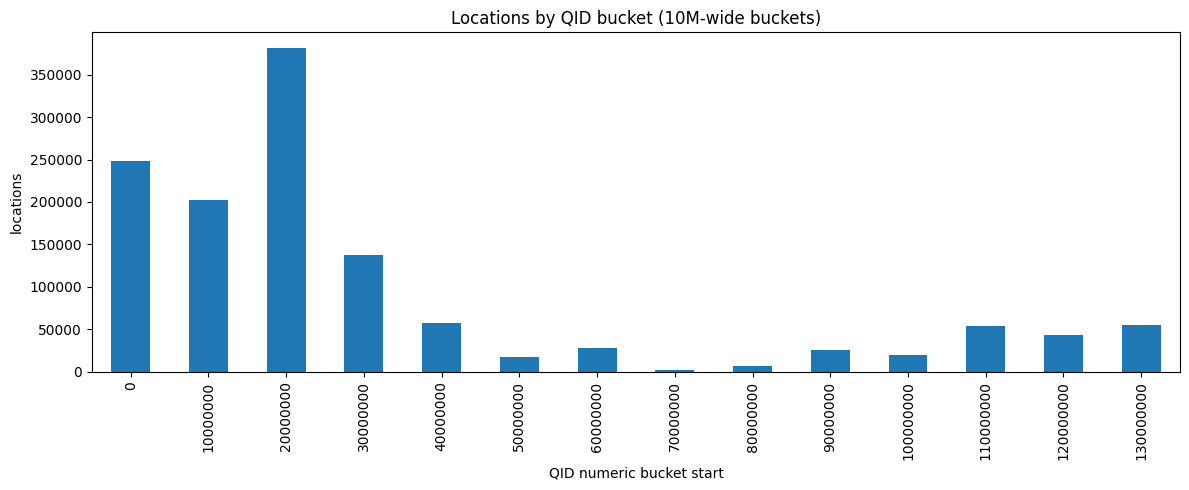

In [25]:

qid_total_by_bucket = qid_buckets.groupby("qid_bucket_start", as_index=False)["locations"].sum()
ax = qid_total_by_bucket.plot.bar(x="qid_bucket_start", y="locations", legend=False, figsize=(12, 5))
ax.set_title("Locations by QID bucket (10M-wide buckets)")
ax.set_xlabel("QID numeric bucket start")
ax.set_ylabel("locations")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [26]:

qid_ventiles = q(f"""
WITH q AS (
    SELECT {qid_num_expr('qid')} AS qid_num, kind
    FROM wikidata_location
    WHERE {qid_num_expr('qid')} IS NOT NULL
), ranked AS (
    SELECT qid_num, kind, NTILE(20) OVER (ORDER BY qid_num) AS qid_ventile
    FROM q
)
SELECT
    qid_ventile,
    MIN(qid_num) AS min_qid_num,
    MAX(qid_num) AS max_qid_num,
    COUNT(*) AS locations,
    COUNT(DISTINCT kind) AS kind_count
FROM ranked
GROUP BY qid_ventile
ORDER BY qid_ventile;
""")
show("QID ventiles", qid_ventiles)

highest_qid_samples = q(f"""
SELECT qid, kind, lat, lon
FROM wikidata_location
WHERE {qid_num_expr('qid')} IS NOT NULL
ORDER BY {qid_num_expr('qid')} DESC
LIMIT {SAMPLE_LIMIT};
""")
show("Sample: highest-QID surviving locations", highest_qid_samples)


### QID ventiles

,qid_ventile,min_qid_num,max_qid_num,locations,kind_count
0,1,16,2225729,63772,28
1,2,2225743,4242887,63772,26
2,3,4242909,5798127,63772,26
3,4,5798129,10753198,63772,26
4,5,10753201,13637547,63772,26
5,6,13637558,18132811,63772,24
6,7,18132813,19887285,63772,22
7,8,19887290,20301811,63772,21
8,9,20301812,21886254,63772,23
9,10,21886258,22446208,63772,19


### Sample: highest-QID surviving locations

,qid,kind,lat,lon
0,Q139329366,river,6.693454,-65.371197
1,Q139329335,river,6.762652,-65.498176
2,Q139328853,river,6.424601,-65.486552
3,Q139328839,river,6.377252,-65.542242
4,Q139328829,river,6.401905,-65.555492
5,Q139328827,river,NaN,NaN
6,Q139328751,river,6.808971,-65.686780
7,Q139328686,river,6.661299,-65.445870
8,Q139328603,river,6.880198,-65.609304
9,Q139326324,river,28.150839,-99.034470


,qid,kind,lat,lon
0,Q139329366,river,6.693454,-65.371197
1,Q139329335,river,6.762652,-65.498176
2,Q139328853,river,6.424601,-65.486552
3,Q139328839,river,6.377252,-65.542242
4,Q139328829,river,6.401905,-65.555492
5,Q139328827,river,NaN,NaN
6,Q139328751,river,6.808971,-65.686780
7,Q139328686,river,6.661299,-65.445870
8,Q139328603,river,6.880198,-65.609304
9,Q139326324,river,28.150839,-99.034470


In [27]:

qid_kind_pivot = qid_buckets.pivot_table(
    index="qid_bucket_start",
    columns="kind",
    values="locations",
    aggfunc="sum",
    fill_value=0,
)
# Show only the most common kinds as columns to keep the table readable.
top_kind_cols = kind_overview.head(15)["kind"].tolist()
qid_kind_pivot_top = qid_kind_pivot[[c for c in top_kind_cols if c in qid_kind_pivot.columns]]
show("QID bucket pivot for top kinds", qid_kind_pivot_top.reset_index())


### QID bucket pivot for top kinds

kind,qid_bucket_start,settlement,river,lake,village,island,hamlet,bay,peninsula,mountain_range,town,city,admin_division,municipality,historical_country,strait
0,0,59420,46886,9418,73722,10001,20477,1977,1210,3265,8707,6908,987,1135,1721,448
1,10000000,71020,11305,42936,40720,2699,27933,559,258,654,765,568,1057,803,289,172
2,20000000,87405,92695,79353,12459,54784,17762,12912,14422,4801,458,308,625,412,99,470
3,30000000,8765,86038,16543,5609,10293,678,3869,431,4713,223,60,58,22,8,374
4,40000000,22374,2793,8751,496,13141,205,7957,426,645,86,28,117,9,12,58
5,50000000,8328,3642,961,2856,319,320,35,22,100,47,29,142,32,62,11
6,60000000,12944,2230,3158,8382,306,457,60,36,39,53,26,92,8,27,35
7,70000000,665,91,315,212,34,156,4,4,3,7,2,13,3,2,2
8,80000000,1614,411,3279,1289,39,159,20,5,17,27,30,53,7,13,0
9,90000000,18663,3050,1172,1621,127,321,43,11,24,30,149,104,10,24,4


kind,qid_bucket_start,settlement,river,lake,village,island,hamlet,bay,peninsula,mountain_range,town,city,admin_division,municipality,historical_country,strait
0,0,59420,46886,9418,73722,10001,20477,1977,1210,3265,8707,6908,987,1135,1721,448
1,10000000,71020,11305,42936,40720,2699,27933,559,258,654,765,568,1057,803,289,172
2,20000000,87405,92695,79353,12459,54784,17762,12912,14422,4801,458,308,625,412,99,470
3,30000000,8765,86038,16543,5609,10293,678,3869,431,4713,223,60,58,22,8,374
4,40000000,22374,2793,8751,496,13141,205,7957,426,645,86,28,117,9,12,58
5,50000000,8328,3642,961,2856,319,320,35,22,100,47,29,142,32,62,11
6,60000000,12944,2230,3158,8382,306,457,60,36,39,53,26,92,8,27,35
7,70000000,665,91,315,212,34,156,4,4,3,7,2,13,3,2,2
8,80000000,1614,411,3279,1289,39,159,20,5,17,27,30,53,7,13,0
9,90000000,18663,3050,1172,1621,127,321,43,11,24,30,149,104,10,24,4


## 10. Actionable issue scorecard

This scorecard distills the preceding sections into a few counts that are likely to affect the lookup engine.


In [28]:

issue_queries = [
    ("locations with no names", "SELECT COUNT(*) FROM wikidata_location l LEFT JOIN wikidata_location_name n ON n.qid = l.qid WHERE n.qid IS NULL"),
    ("locations with no mapped-language names", "SELECT COUNT(*) FROM wikidata_location l LEFT JOIN wikidata_location_name n ON n.qid = l.qid AND n.geo_lang IS NOT NULL WHERE n.qid IS NULL"),
    ("name rows with geo_lang NULL", "SELECT COUNT(*) FROM wikidata_location_name WHERE geo_lang IS NULL"),
    ("name rows with empty name_norm", "SELECT COUNT(*) FROM wikidata_location_name WHERE name_norm = ''"),
    ("locations with invalid/partial coordinates", "SELECT COUNT(*) FROM wikidata_location WHERE (lat IS NULL) <> (lon IS NULL) OR lat < -90 OR lat > 90 OR lon < -180 OR lon > 180"),
    ("locations with no P31 row", "SELECT COUNT(*) FROM wikidata_location l LEFT JOIN wikidata_location_p31 p ON p.qid = l.qid WHERE p.qid IS NULL"),
    ("locations with GeoNames link", "SELECT COUNT(DISTINCT qid) FROM wikidata_location_geonames"),
    ("ambiguous mapped lookup keys", "SELECT COUNT(*) FROM (SELECT geo_lang, name_norm FROM wikidata_location_name WHERE geo_lang IS NOT NULL GROUP BY geo_lang, name_norm HAVING COUNT(DISTINCT qid) > 1)"),
]

total_locations = scalar("SELECT COUNT(*) FROM wikidata_location")
total_names = scalar("SELECT COUNT(*) FROM wikidata_location_name")
rows = []
for label, sql in issue_queries:
    n = scalar(sql)
    denominator = total_names if label.startswith("name rows") else total_locations
    rows.append({
        "metric": label,
        "n": n,
        "denominator": denominator,
        "pct_of_denominator": pct(n, denominator),
    })
issue_scorecard = pd.DataFrame(rows).sort_values("n", ascending=False)
show("QC issue scorecard", issue_scorecard)


### QC issue scorecard

,metric,n,denominator,pct_of_denominator
6,locations with GeoNames link,729456,1275439,57.192543
7,ambiguous mapped lookup keys,354976,1275439,27.831672
0,locations with no names,55,1275439,0.004312
1,locations with no mapped-language names,55,1275439,0.004312
4,locations with invalid/partial coordinates,16,1275439,0.001254
2,name rows with geo_lang NULL,0,7156042,0.000000
3,name rows with empty name_norm,0,7156042,0.000000
5,locations with no P31 row,0,1275439,0.000000


,metric,n,denominator,pct_of_denominator
6,locations with GeoNames link,729456,1275439,57.192543
7,ambiguous mapped lookup keys,354976,1275439,27.831672
0,locations with no names,55,1275439,0.004312
1,locations with no mapped-language names,55,1275439,0.004312
4,locations with invalid/partial coordinates,16,1275439,0.001254
2,name rows with geo_lang NULL,0,7156042,0.000000
3,name rows with empty name_norm,0,7156042,0.000000
5,locations with no P31 row,0,1275439,0.000000
